In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Подготовка набора данных

In [3]:
(penguins := pd.read_csv("penguins.csv"))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [4]:
penguins = penguins[penguins.bill_length_mm.notna()]
penguins[penguins.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [5]:
penguins = penguins.fillna("unknown")
penguins_adelie = penguins[penguins.species == "Adelie"]
penguins_gentoo = penguins[penguins.species == "Gentoo"]
penguins_chinstrap = penguins[penguins.species == "Chinstrap"]
label_male, label_female, label_unknown = "Самцы", "Самки", "Неизвестно"
hue_male, hue_female, hue_unknown = "male", "female", "unknown"
color_male, color_female, color_unknown = "#4c72b0", "#dd8452", "#55a868"
palette_sex = {hue_male: color_male, hue_female: color_female, hue_unknown: color_unknown}
marker_male = Line2D([], [], color=color_male, linestyle="None", marker=".", markersize=8)
marker_female = Line2D([], [], color=color_female, linestyle="None", marker=".", markersize=8)
marker_unknown = Line2D([], [], color=color_unknown, linestyle="None", marker=".", markersize=16)

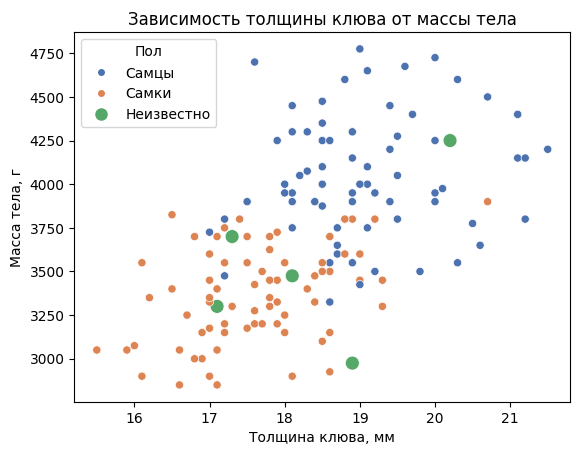

In [6]:
sns.scatterplot(
    penguins_adelie, x=penguins_adelie.bill_depth_mm, y=penguins_adelie.body_mass_g,
    hue="sex", size="sex",
    palette=palette_sex, hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

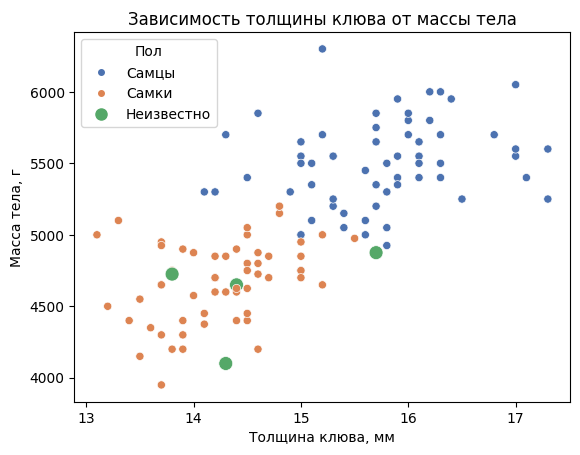

In [7]:
sns.scatterplot(
    penguins_gentoo, x=penguins_gentoo.bill_depth_mm, y=penguins_gentoo.body_mass_g,
    hue="sex", size="sex", palette=palette_sex,
    hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

In [8]:
penguins_adelie[penguins_adelie.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,unknown
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,unknown
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,unknown
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,unknown
47,Adelie,Dream,37.5,18.9,179.0,2975.0,unknown


In [9]:
penguins_gentoo[penguins_gentoo.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,unknown
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,unknown
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,unknown
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,unknown


In [10]:
penguins_adelie.at[8, "sex"] = "female"
penguins_adelie.at[9, "sex"] = "male"
penguins_adelie.at[10, "sex"] = "female"
penguins_adelie.at[11, "sex"] = "female"
penguins_adelie.at[47, "sex"] = "female"
penguins_gentoo.at[178, "sex"] = "female"
penguins_gentoo.at[218, "sex"] = "female"
penguins_gentoo.at[256, "sex"] = "female"
penguins_gentoo.at[268, "sex"] = "male"

In [11]:
(penguins := pd.concat([penguins_adelie, penguins_gentoo, penguins_chinstrap]))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [12]:
one_hot_encoder = OneHotEncoder()
encoded_species = one_hot_encoder.fit_transform(penguins[["species"]])
penguins[["adelie", "chinstrap", "gentoo"]] = encoded_species.toarray()
encoded_island = one_hot_encoder.fit_transform(penguins[["island"]])
penguins[["biscoe", "dream", "torgersen"]] = encoded_island.toarray()
penguins.drop(columns=["species", "island"], inplace=True)
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,male,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,female,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,female,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,female,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,male,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,male,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,female,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,male,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,male,0.0,1.0,0.0,0.0,1.0,0.0


In [13]:
penguins.sex = penguins.sex.map({"female": 0, "male": 1})
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,1,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,1,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,1,0.0,1.0,0.0,0.0,1.0,0.0


In [14]:
(y := penguins.sex)

0      1
1      0
2      0
4      0
5      1
      ..
339    1
340    0
341    1
342    1
343    0
Name: sex, Length: 342, dtype: int64

In [15]:
(X := penguins.drop(columns="sex"))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,0.0,1.0,0.0,0.0,1.0,0.0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Виды ансамблей и сложность их реализации

**По построению:**
- Бэггинг — модели обучаются независимо, а затем ответ получается голосованием или усреднением вероятностей;
- Бустинг — каждая новая модель исправляет ошибки предыдущих;
- Стекинг — сначала обучаются базовые модели, а затем передают свои ответы последней, выдающей итоговый ответ.

**По методу получения обучающих выборок:**
- Выборка с возвращением (bootstrap) — бэггинг;
- Изменение весов объектов — бустинг;
- Каждый базовый алгоритм использует всю выборку целиком — стекинг.

**По способу принятия решения:**
- Простое или взвешенное голосование — бэггинг, адаптивный бустинг;
- Усреднение вероятностей — случайный лес, градиентный бустинг;
- Мета-модель — стекинг.

**По сложности самостоятельной реализации:**
- Бэггинг — необходимо обучить несколько моделей на различных обучающих выборках и усреднить их результаты;
- Случайный лес — бэггинг со случайным отбором признаков при каждом разбиении;
- Адаптивный бустинг — нужно хранить и обновлять веса объектов, выбирать веса моделей;
- Стекинг — требует аккуратного разделения данных и генерации мета-признаков через кросс-валидацию;
- Градиентный бустинг — требует расчёта градиентов, работы с произвольной функцией потерь, управления скоростью обучения, регуляризации.

# Своя реализация случайного леса

In [17]:
class MyDecisionTreeClassifier:
    class Node:
        def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value
        
        def is_leaf(self):
            return self.value is not None
    
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_classes_ = None
        self.n_features_in_ = None
        
        if self.criterion not in ["gini", "entropy"]:
            raise ValueError("Ошибка: недопустимое значение criterion")
    
    def __gini(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def __entropy(self, y):
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return -np.sum(probs * np.log2(probs))
    
    def __impurity(self, y):
        if len(y) == 0:
            return 0
        if self.criterion == "gini":
            return self.__gini(y)
        return self.__entropy(y)
    
    def __best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -float("inf")
        best_feature_index = None
        best_threshold = None
        
        if n_samples <= 1:
            return best_feature_index, best_threshold, best_gain
        
        current_impurity = self.__impurity(y)
        
        for feature_index in range(n_features):
            feature_values = np.unique(X[:, feature_index])
            
            thresholds = (feature_values[:-1] + feature_values[1:]) / 2
            
            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue
                
                left_impurity = self.__impurity(y_left)
                right_impurity = self.__impurity(y_right)
                n_left, n_right = len(y_left), len(y_right)
                
                weighted_impurity = (n_left * left_impurity + n_right * right_impurity) / n_samples
                
                gain = current_impurity - weighted_impurity
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold
        
        return best_feature_index, best_threshold, best_gain
    
    def __build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        
        if (self.max_depth is not None and depth >= self.max_depth or
            n_samples < self.min_samples_split or
            len(np.unique(y)) == 1):
            
            most_common = Counter(y).most_common(1)[0][0]
            return self.Node(value=most_common)
        
        best_feature, best_threshold, best_gain = self.__best_split(X, y)
        
        if best_feature is None or best_gain <= 0:
            most_common = Counter(y).most_common(1)[0][0]
            return self.Node(value=most_common)
        
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        left_subtree = self.__build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.__build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return self.Node(feature_index=best_feature, threshold=best_threshold, left=left_subtree, right=right_subtree)
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        self.n_classes_ = len(np.unique(y))
        
        self.root = self.__build_tree(X, y)
        
        return self
    
    def __predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self.__predict_sample(x, node.left)
        else:
            return self.__predict_sample(x, node.right)
    
    def predict(self, X):
        if self.root is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        preds = [self.__predict_sample(x, self.root) for x in X]
        return np.array(preds)
    
    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), self.n_classes_))
        for i, pred in enumerate(preds):
            proba[i, pred] = 1.0
        return proba
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=int)
        return np.mean(y_pred == y_true)

In [18]:
class MyRandomForestClassifier:
    def __init__(self, n_estimators=100, max_features="sqrt", bootstrap=True, random_state=None, **tree_kwargs):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.tree_kwargs = tree_kwargs
        
        self.estimators_ = []
        self.features_used_ = []
        self.n_features_in_ = None
        self.classes_ = None
        self.n_classes_ = None
        
    def __get_max_features(self, n_features):
        if self.max_features is None:
            return n_features
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        elif isinstance(self.max_features, float):
            return max(1, int(self.max_features * n_features))
        elif self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        elif self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        else:
            raise ValueError(f"Ошибка: неподдерживаемое значение max_features {self.max_features}")
    
    def __bootstrap_sample(self, X, y, random_state):
        n_samples = X.shape[0]
        random_generator = np.random.RandomState(random_state)
        indices = random_generator.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        
        n_features_for_tree = self.__get_max_features(self.n_features_in_)
        
        random_generator = np.random.RandomState(self.random_state)
        
        for i in range(self.n_estimators):
            feature_indices = random_generator.choice(
                self.n_features_in_,
                size=n_features_for_tree,
                replace=False
            )
            
            if self.bootstrap:
                seed = random_generator.randint(0, 2 ** 31 - 1) if self.random_state is not None else None
                X_sample, y_sample = self.__bootstrap_sample(X[:, feature_indices], y, seed)
            else:
                X_sample = X[:, feature_indices]
                y_sample = y
            
            tree = MyDecisionTreeClassifier(**self.tree_kwargs)
            tree.fit(X_sample, y_sample)
            
            self.estimators_.append(tree)
            self.features_used_.append(feature_indices)
        
        return self
    
    def predict(self, X):
        if not self.estimators_:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        n_samples = X.shape[0]
        all_predictions = np.zeros((n_samples, self.n_estimators), dtype=int)
        
        for i, (tree, features) in enumerate(zip(self.estimators_, self.features_used_)):
            X_subset = X[:, features]
            all_predictions[:, i] = tree.predict(X_subset)
        
        y_pred = np.zeros(n_samples, dtype=int)
        for i in range(n_samples):
            counts = Counter(all_predictions[i])
            y_pred[i] = counts.most_common(1)[0][0]
        
        return y_pred
    
    def predict_proba(self, X):
        if not self.estimators_:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        n_samples = X.shape[0]
        proba = np.zeros((n_samples, self.n_classes_))
        
        all_predictions = np.zeros((n_samples, self.n_estimators), dtype=int)
        for i, (tree, features) in enumerate(zip(self.estimators_, self.features_used_)):
            X_subset = X[:, features]
            all_predictions[:, i] = tree.predict(X_subset)
        
        for i in range(n_samples):
            counts = Counter(all_predictions[i])
            for j, cls in enumerate(self.classes_):
                proba[i, j] = counts.get(cls, 0) / self.n_estimators
        
        return proba
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=int)
        return np.mean(y_pred == y_true)

# Сравнение библиотечной реализации со своей

In [19]:
forest1 = RandomForestClassifier(random_state=5)
forest1.fit(X_train, y_train)
forest1.score(X_test, y_test)

0.9223300970873787

In [68]:
forest2 = MyRandomForestClassifier(random_state=5)
forest2.fit(X_train, y_train)
forest2.score(X_test, y_test)

np.float64(0.941747572815534)

In [21]:
forest1.predict_proba(X_test[:10])

array([[0.05, 0.95],
       [0.87, 0.13],
       [0.13, 0.87],
       [0.61, 0.39],
       [0.  , 1.  ],
       [0.07, 0.93],
       [0.26, 0.74],
       [0.79, 0.21],
       [0.  , 1.  ],
       [0.66, 0.34]])

In [22]:
forest2.predict_proba(X_test[:10])

array([[0.29, 0.71],
       [0.57, 0.43],
       [0.46, 0.54],
       [0.57, 0.43],
       [0.29, 0.71],
       [0.21, 0.79],
       [0.45, 0.55],
       [0.57, 0.43],
       [0.12, 0.88],
       [0.7 , 0.3 ]])

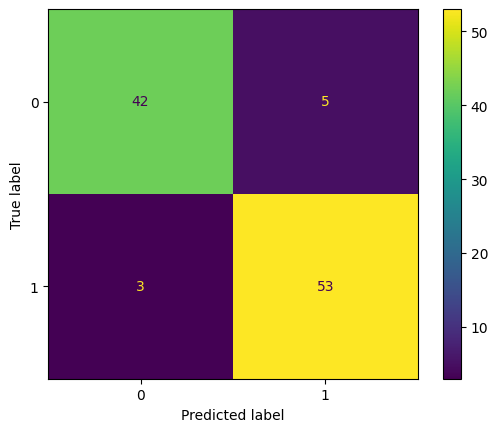

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, forest1.predict(X_test));

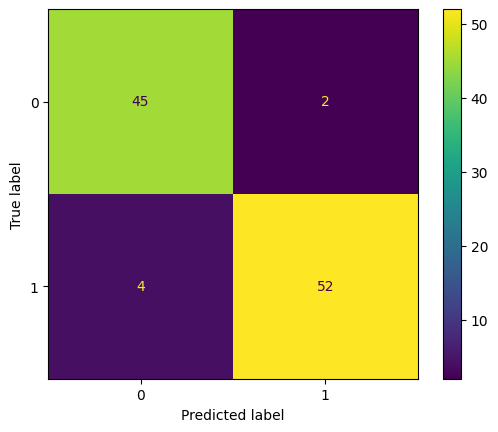

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, forest2.predict(X_test));

# Своя реализация другого ансамбля

In [77]:
class MyAdaBoostClassifier:
    def __init__(self, n_estimators=50, random_state=None):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators_ = []
        self.estimator_weights_ = []
        self.classes_ = None
        self.n_classes_ = None
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("Ошибка: данная реализация поддерживает только бинарную классификацию")
        self.n_classes_ = 2
        
        n_samples = X.shape[0]
        
        w = np.full(n_samples, 1 / n_samples)
        
        for t in range(self.n_estimators):
            random_generator = np.random.RandomState(self.random_state)
            indices = random_generator.choice(n_samples, size=n_samples, replace=True, p=w)
            X_sample, y_sample = X[indices], y[indices]
            
            stump = MyDecisionTreeClassifier(max_depth=1)
            stump.fit(X_sample, y_sample)
            
            y_pred = stump.predict(X)
            
            incorrect = (y_pred != y).astype(int)
            err = np.sum(w * incorrect) / np.sum(w)
            
            if err >= 0.5:
                break
            if err == 0:
                self.estimator_weights_.append(1.0)
                self.estimators_.append(stump)
                break
            
            alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
            self.estimator_weights_.append(alpha)
            self.estimators_.append(stump)
            
            w = w * np.exp(-alpha * (2 * (y_pred == y) - 1))
            w = w / np.sum(w)
        
        return self
    
    def predict(self, X):
        if not self.estimators_:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        votes = np.zeros((X.shape[0], self.n_classes_))
        
        for alpha, stump in zip(self.estimator_weights_, self.estimators_):
            pred = stump.predict(X)
            for i, p in enumerate(pred):
                votes[i, p] += alpha
        
        return np.argmax(votes, axis=1)

    def predict_proba(self, X):
        if not self.estimators_:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        votes = np.zeros((X.shape[0], self.n_classes_))
        for alpha, stump in zip(self.estimator_weights_, self.estimators_):
            pred = stump.predict(X)
            for i, p in enumerate(pred):
                votes[i, p] += alpha
        
        votes_shifted = votes - np.max(votes, axis=1, keepdims=True)
        exp_votes = np.exp(votes_shifted)
        proba = exp_votes / np.sum(exp_votes, axis=1, keepdims=True)
        
        if np.any(np.isnan(proba)):
            proba = np.full((X.shape[0], self.n_classes_), 1.0 / self.n_classes_)
        
        return proba
    
    def score(self, X, y) -> float:
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=int)
        return np.mean(y_pred == y_true)

# Сравнение библиотечной реализации со своей

In [78]:
boost1 = AdaBoostClassifier(random_state=8)
boost1.fit(X_train, y_train)
boost1.score(X_test, y_test)

0.8932038834951457

In [79]:
boost2 = MyAdaBoostClassifier(random_state=8)
boost2.fit(X_train, y_train)
boost2.score(X_test, y_test)

np.float64(0.9223300970873787)

In [80]:
boost1.predict_proba(X_test[:10])

array([[0.40000259, 0.59999741],
       [0.59660701, 0.40339299],
       [0.45152411, 0.54847589],
       [0.52752461, 0.47247539],
       [0.30823125, 0.69176875],
       [0.3901898 , 0.6098102 ],
       [0.44932783, 0.55067217],
       [0.56098389, 0.43901611],
       [0.24692174, 0.75307826],
       [0.49418466, 0.50581534]])

In [81]:
boost2.predict_proba(X_test[:10])

array([[0.11549455, 0.88450545],
       [0.84802803, 0.15197197],
       [0.26204611, 0.73795389],
       [0.64266763, 0.35733237],
       [0.02936759, 0.97063241],
       [0.14398621, 0.85601379],
       [0.29238535, 0.70761465],
       [0.76355563, 0.23644437],
       [0.00751962, 0.99248038],
       [0.54651932, 0.45348068]])

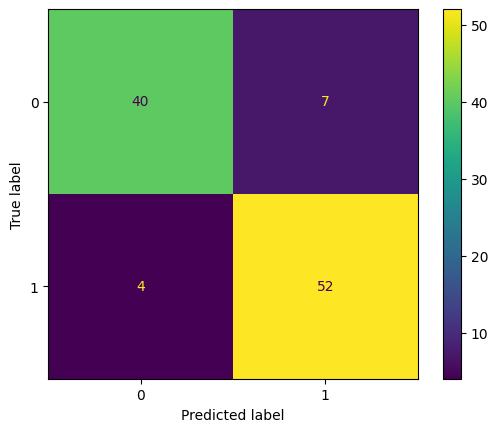

In [82]:
ConfusionMatrixDisplay.from_predictions(y_test, boost1.predict(X_test));

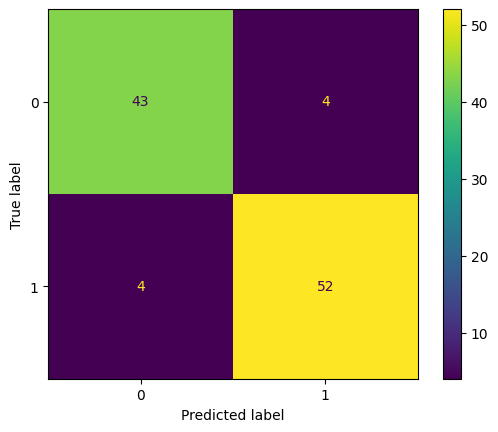

In [83]:
ConfusionMatrixDisplay.from_predictions(y_test, boost2.predict(X_test));